# ViT Defect Inspection — Colab

Train a from-scratch Vision Transformer to classify **cracked vs intact** surfaces, then visualise where it looks with attention rollout.

Runtime: set **Runtime → Change runtime type → GPU**.

In [1]:
# Clone the repo and install dependencies
!git clone -q https://github.com/bukhorizainun/vit-defect-inspection.git
%cd vit-defect-inspection
!pip -q install timm kagglehub

/content/vit-defect-inspection


In [2]:
# Download the public Surface Crack dataset (Positive/Negative folders)
import os, kagglehub

path = kagglehub.dataset_download("arunrk7/surface-crack-detection")

def find_root(p):
    for root, dirs, _ in os.walk(p):
        if "Positive" in dirs and "Negative" in dirs:
            return root
    return p

data_dir = find_root(path)
print("data_dir:", data_dir)
print("classes :", sorted(os.listdir(data_dir)))

Using Colab cache for faster access to the 'surface-crack-detection' dataset.
data_dir: /kaggle/input/surface-crack-detection
classes : ['Negative', 'Positive']


In [3]:
# Train the from-scratch ViT
#    (swap in `--pretrained --epochs 5` to fine-tune a timm ViT instead)
!python -m src.train --data-dir "{data_dir}" --epochs 15 --batch-size 128 --lr 3e-4

device: cuda
classes: ['Negative', 'Positive']
model: from-scratch vit_tiny  params: 2,855,618
epoch 01  train_loss 0.1499  val_acc 0.9858
epoch 02  train_loss 0.0459  val_acc 0.9895
epoch 03  train_loss 0.0350  val_acc 0.9928
epoch 04  train_loss 0.0279  val_acc 0.9952
epoch 05  train_loss 0.0189  val_acc 0.9950
epoch 06  train_loss 0.0175  val_acc 0.9969
epoch 07  train_loss 0.0143  val_acc 0.9954
epoch 08  train_loss 0.0130  val_acc 0.9971
epoch 09  train_loss 0.0111  val_acc 0.9975
epoch 10  train_loss 0.0098  val_acc 0.9959
epoch 11  train_loss 0.0096  val_acc 0.9975
epoch 12  train_loss 0.0087  val_acc 0.9976
epoch 13  train_loss 0.0071  val_acc 0.9978
epoch 14  train_loss 0.0068  val_acc 0.9976
epoch 15  train_loss 0.0066  val_acc 0.9978
best val_acc: 0.9978  ->  results/best.pt


In [4]:
# Report best validation accuracy and confusion matrix
import json
h = json.load(open("results/history.json"))
print("model       :", h["tag"])
print("classes     :", h["classes"])
print("best val_acc:", round(h["best_val_acc"], 4))
print("confusion   :", h["confusion_matrix"])

model       : from-scratch vit_tiny
classes     : ['Negative', 'Positive']
best val_acc: 0.9978
confusion   : [[3967, 6], [12, 4015]]


saved attention overlays to assets/


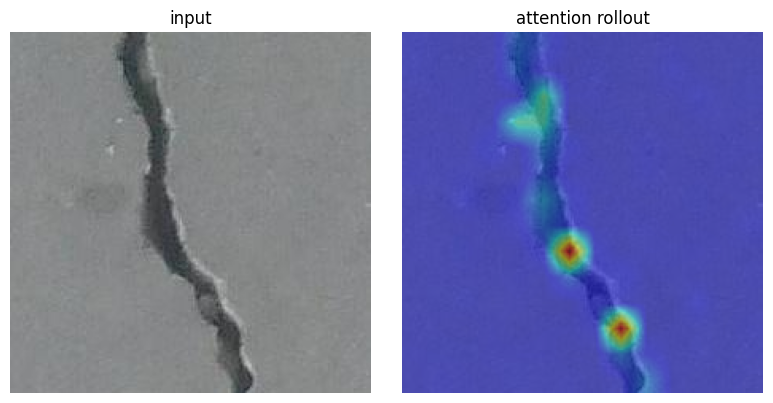

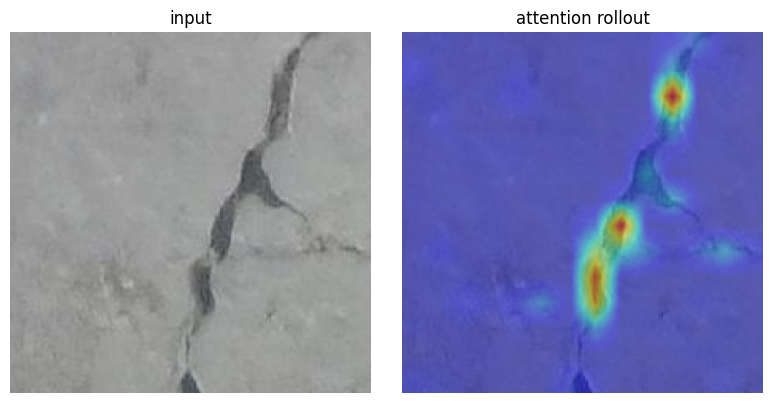

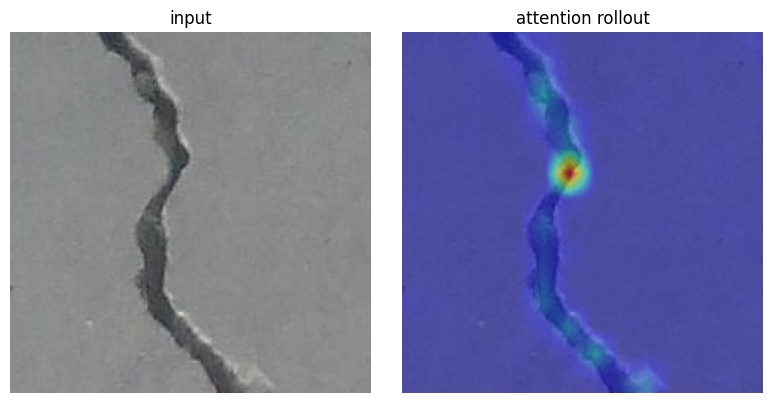

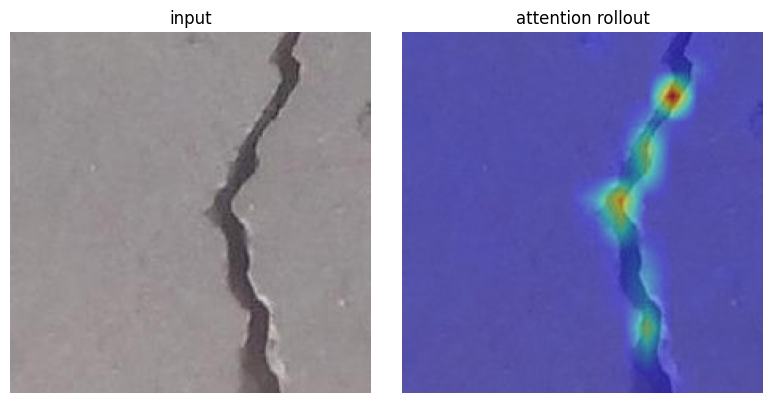

In [5]:
# Attention rollout on a few cracked images
import glob, os, torch
from PIL import Image
from src.vit import vit_tiny
from src.data import build_transforms
from src.attention import attention_rollout, overlay_attention

ckpt = torch.load("results/best.pt", map_location="cpu")
model = vit_tiny(img_size=224, n_classes=len(ckpt["classes"]))
model.load_state_dict(ckpt["model"])
model.eval()

tf = build_transforms(224, train=False)
os.makedirs("assets", exist_ok=True)
samples = sorted(glob.glob(os.path.join(data_dir, "Positive", "*")))[:4]

for i, fp in enumerate(samples):
    img = Image.open(fp).convert("RGB")
    x = tf(img).unsqueeze(0)
    mask = attention_rollout(model, x, device="cpu")
    overlay_attention(img, mask, out_path=f"assets/rollout_{i}.png")
print("saved attention overlays to assets/")